<a href="https://colab.research.google.com/github/jannat-miftahul/Mobile-Price-Range-Predictor/blob/main/mobile_price_range_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mobile Price Range Classification**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# sklearn preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Metrics
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV

import warnings
warnings.filterwarnings("ignore")

## **1. Data Loading**

In [ ]:
# Upload mobile-price.zip using the Colab file panel, then run:
from google.colab import files
uploaded = files.upload()   # choose mobile-price.zip
import zipfile
with zipfile.ZipFile("mobile-price.zip", "r") as z:
    z.extractall(".")

df = pd.read_csv("train.csv")
df.head()

Saving archive.zip to archive (2).zip


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
print("Shape:", df.shape)

Shape: (2000, 21)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [ ]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


## **Y Data Profiling**

In [ ]:
!pip install ydata-profiling -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.6 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Mobile Price Range Classification", explorative=True)
profile.to_file("mobile_price_ydata.html")
print("Profile report saved as mobile_price_ydata.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:00<00:00, 24.70it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profile report saved as mobile_price_ydata.html


## **2. Data Preprocessing**

### Step 1: Check Missing Values

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Total missing: 0


### Step 2: Check for Duplicate Rows

In [ ]:
print(f"Duplicate rows before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows before: 0
Shape after removing duplicates: (2000, 21)


### Step 3: Outlier Detection (IQR Method)

In [ ]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.drop("price_range")

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({"Feature": col, "Outlier Count": n_out})

print(pd.DataFrame(outlier_summary).to_string(index=False))

      Feature  Outlier Count
battery_power              0
         blue              0
  clock_speed              0
     dual_sim              0
           fc             18
       four_g              0
   int_memory              0
        m_dep              0
    mobile_wt              0
      n_cores              0
           pc              0
    px_height              2
     px_width              0
          ram              0
         sc_h              0
         sc_w              0
    talk_time              0
      three_g            477
 touch_screen              0
         wifi              0


### Step 4: Feature Engineering — Pixel Area & Screen Area

In [ ]:
df["pixel_area"]  = df["px_height"] * df["px_width"]
df["screen_area"] = df["sc_h"]       * df["sc_w"]

print("New features added: pixel_area, screen_area")
df[["px_height","px_width","pixel_area","sc_h","sc_w","screen_area"]].head()

New features added: pixel_area, screen_area


,px_height,px_width,pixel_area,sc_h,sc_w,screen_area
0,20,756,15120,9,7,63
1,905,1988,1799140,17,3,51
2,1263,1716,2167308,11,2,22
3,1216,1786,2171776,16,8,128
4,1208,1212,1464096,8,2,16


### Step 5: Correlation Analysis

In [ ]:
corr = df.corr()["price_range"].sort_values(ascending=False)
print("Correlation with price_range:")
print(corr)

Correlation with price_range:
price_range      1.000000
ram              0.917046
battery_power    0.200723
pixel_area       0.176240
px_width         0.165818
px_height        0.148858
int_memory       0.044435
screen_area      0.041248
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


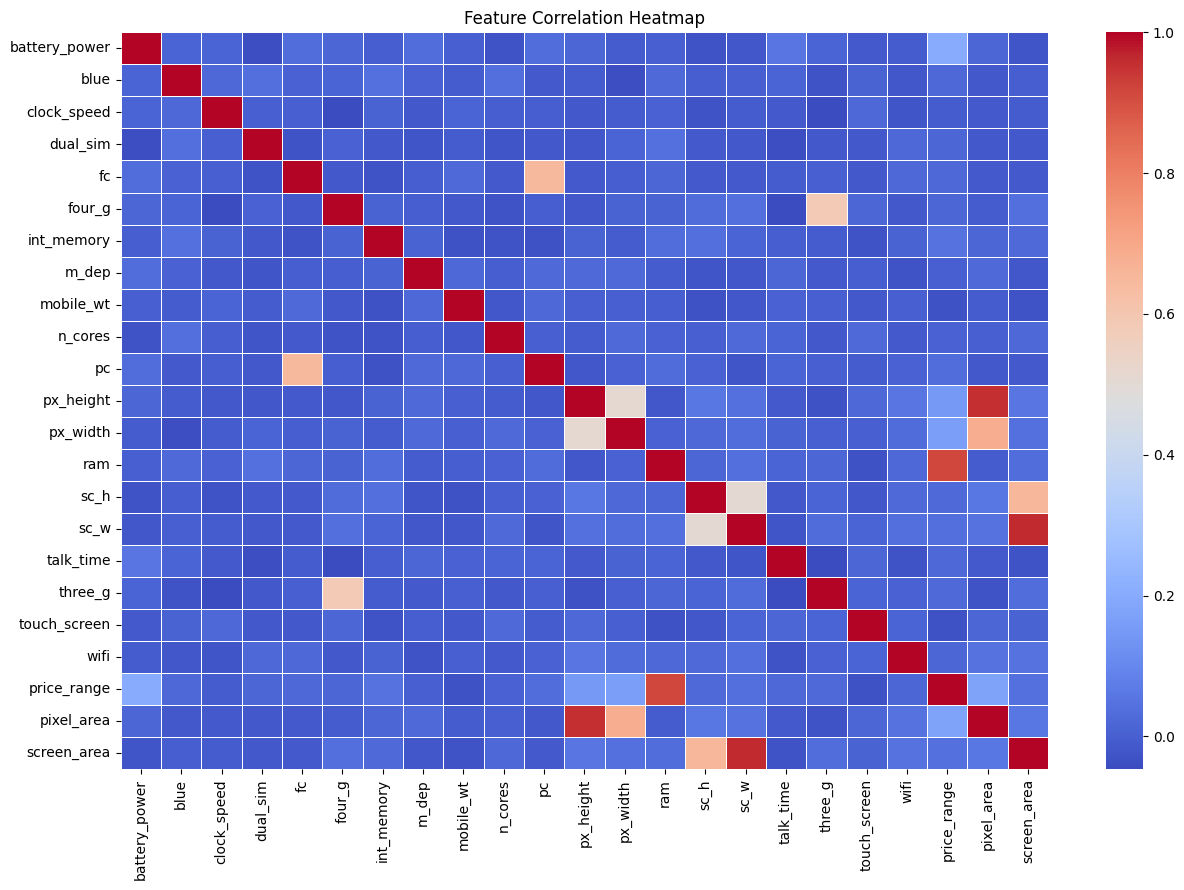

In [ ]:
plt.figure(figsize=(13,9))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", linewidths=0.4)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Step 6: Identify Feature Types (for Pipeline)

In [ ]:
binary_cols     = ["blue","dual_sim","four_g","three_g","touch_screen","wifi"]
continuous_cols = [c for c in df.drop("price_range", axis=1).columns
                   if c not in binary_cols]
print("Binary (flag) features:", binary_cols)
print("\nContinuous features    :", continuous_cols)

Binary (flag) features: ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

Continuous features    : ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'pixel_area', 'screen_area']


### Step 7: Train-Test Split

In [ ]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"\nClass distribution in train:\n{y_train.value_counts().sort_index()}")

Train size : (1600, 22)
Test size  : (400, 22)

Class distribution in train:
price_range
0    400
1    400
2    400
3    400
Name: count, dtype: int64


## **3. Pipeline Creation**

In [ ]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()

# Numeric transformer: impute median + standard scale
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# ColumnTransformer (all features are numeric in this dataset)
preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, numeric_features)
])

print("Preprocessor pipeline created successfully.")
print(f"Features to transform: {len(numeric_features)}")

Preprocessor pipeline created successfully.
Features to transform: 22


## **4. Primary Model Selection**

### Why Random Forest Classifier?

| Reason | Detail |
|---|---|
| **Multi-class native** | `price_range` has 4 classes (0–3); RF handles this without one-vs-rest wrappers |
| **High accuracy on tabular data** | Ensemble of decision trees reduces variance and overfitting |
| **No linear separability needed** | Works well with non-linear boundaries common in hardware specs |
| **Robust to outliers** | Tree splits are rank-based, not distance-based |
| **Feature importance** | Naturally ranks which hardware specs drive price |
| **Baseline comparison** | Logistic Regression and Gradient Boosting trained in parallel for validation |

## **5. Model Training**

In [ ]:
# Define base classifiers
clf_lr  = LogisticRegression(max_iter=1000, random_state=42)
clf_rf  = RandomForestClassifier(n_estimators=100, random_state=42)
clf_gb  = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Voting Classifier (soft voting uses predicted probabilities)
voting_clf = VotingClassifier(
    estimators=[("lr", clf_lr), ("rf", clf_rf), ("gb", clf_gb)],
    voting="soft"
)

# Stacking Classifier (meta-learner = Logistic Regression)
stacking_clf = StackingClassifier(
    estimators=[("rf", clf_rf), ("gb", clf_gb)],
    final_estimator=LogisticRegression(max_iter=1000)
)

In [ ]:
models_to_train = {
    "Logistic Regression" : clf_lr,
    "Random Forest"       : clf_rf,
    "Gradient Boosting"   : clf_gb,
    "Voting Ensemble"     : voting_clf,
    "Stacking Ensemble"   : stacking_clf
}

results = []

for name, model in models_to_train.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model",         model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": round(acc, 4)})

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy
Logistic Regression    0.9625
    Voting Ensemble    0.9525
  Gradient Boosting    0.9275
  Stacking Ensemble    0.9250
      Random Forest    0.8925


## **6. Cross-Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

cv_scores = cross_val_score(
    rf_pipeline, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1
)
print("CV Accuracy per fold:", np.round(cv_scores, 4))

CV Accuracy per fold: [0.875  0.8656 0.8594 0.8375 0.8656]


In [ ]:
print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")

Mean Accuracy : 0.8606
Std Deviation : 0.0126


In [ ]:
# Also CV for Gradient Boosting
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(n_estimators=100, random_state=42))
])

cv_gb = cross_val_score(gb_pipeline, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
print(f"GBM CV Accuracy: {cv_gb.mean():.4f} +/- {cv_gb.std():.4f}")

GBM CV Accuracy: 0.8925 +/- 0.0096


## **7. Hyperparameter Tuning**

### Grid Search CV

In [ ]:
rf_pipeline_tune = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators"    : [100, 200],
    "model__max_depth"       : [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator  = rf_pipeline_tune,
    param_grid = param_grid,
    cv         = 5,
    scoring    = "accuracy",
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['battery_power',
                                                                          'blue',
                                                                          'clock_speed',
                                                                          'dual_sim',
                                                                          'fc',
                                                                          'four_g',
                                                                          'int_memory',
                                                                          'm_dep',
                                                                          'mobile_wt',
                                                                          'n_cores',
                                                                          'pc',
                                                                          'px_height',
                                                                          'px_width',
                                                                          'ram',
                                                                          'sc_h',
                                                                          'sc_w',
                                                                          'talk_time',
                                                                          'three_g',
                                                                          'touch_screen',
                                                                          'wifi',
                                                                          'pixel_area',
                                                                          'screen_area'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
print("Best Grid Search Score :", round(grid_search.best_score_, 4))
print("Best Parameters        :", grid_search.best_params_)

Best Grid Search Score : 0.8781
Best Parameters        : {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 100}


### Randomized Search CV

In [ ]:
from scipy.stats import randint

param_dist = {
    "model__n_estimators"    : randint(100, 500),
    "model__max_depth"       : [None, 10, 20, 30],
    "model__min_samples_split": randint(2, 10)
}

random_search = RandomizedSearchCV(
    estimator           = rf_pipeline_tune,
    param_distributions = param_dist,
    n_iter              = 20,
    cv                  = 5,
    scoring             = "accuracy",
    n_jobs              = -1,
    verbose             = 1,
    random_state        = 42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['battery_power',
                                                                                'blue',
                                                                                'clock_speed',
                                                                                'dual_sim',
                                                                                'fc',
                                                                                'four_g',
                                                                                'int_memory',
                                                                                'm_dep',
                                                                                'mobile_wt',
                                                                                'n_cores',
                                                                                'pc',
                                                                                'px_height',
                                                                                'px_width',
                                                                                'ram',
                                                                                'sc_h',
                                                                                'sc_w',...
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c50ca8830e0>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c50d1d10230>},
                   random_state=42, scoring='accuracy', verbose=1)

In [ ]:
print("Best Randomized Search Score:", round(random_search.best_score_, 4))
print("Best Parameters             :", random_search.best_params_)

Best Randomized Search Score: 0.8762
Best Parameters             : {'model__max_depth': 10, 'model__min_samples_split': 4, 'model__n_estimators': 314}


## **8. Best Model Selection**

In [ ]:
print("Grid Search CV Score     :", round(grid_search.best_score_, 4))
print("Randomized Search Score  :", round(random_search.best_score_, 4))

if grid_search.best_score_ >= random_search.best_score_:
    best_search = grid_search
    best_method = "Grid Search CV"
else:
    best_search = random_search
    best_method = "Randomized Search CV"

best_model = best_search.best_estimator_

print(f"\nSelected method : {best_method}")
print("Best Parameters :", best_search.best_params_)

Grid Search CV Score     : 0.8781
Randomized Search Score  : 0.8762

Selected method : Grid Search CV
Best Parameters : {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 100}


## **9. Model Performance Evaluation**

In [ ]:
y_pred_best   = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_best)

print(f"Test Accuracy : {test_accuracy:.4f}")
print()
print("Classification Report:")
print(classification_report(
    y_test, y_pred_best,
    target_names=["Low (0)", "Med-Low (1)", "Med-High (2)", "High (3)"]
))

Test Accuracy : 0.8850

Classification Report:
              precision    recall  f1-score   support

     Low (0)       0.96      0.95      0.95       100
 Med-Low (1)       0.81      0.86      0.83       100
Med-High (2)       0.84      0.78      0.81       100
    High (3)       0.93      0.95      0.94       100

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.88       400
weighted avg       0.89      0.89      0.88       400



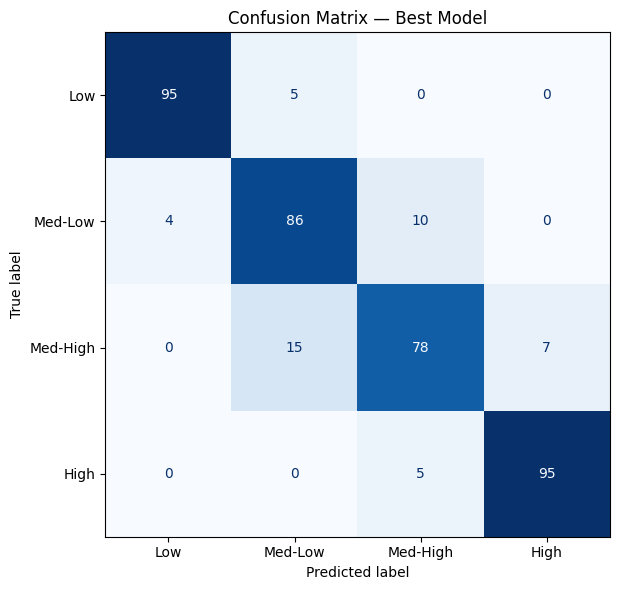

In [ ]:
# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Med-Low", "Med-High", "High"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Best Model")
plt.tight_layout()
plt.show()

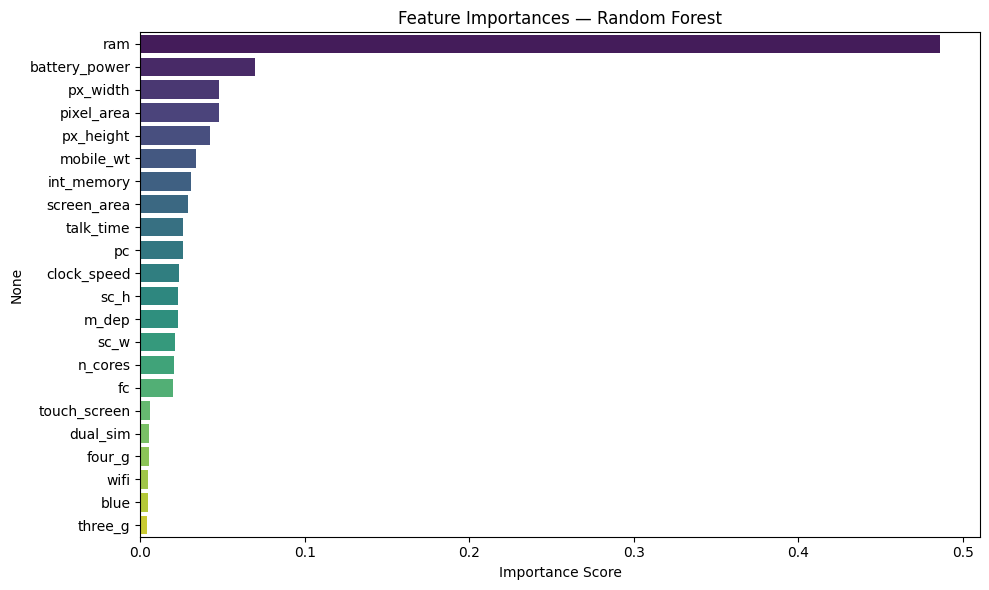

In [ ]:
# Feature Importances
rf_step      = best_model.named_steps["model"]
importances  = pd.Series(rf_step.feature_importances_,
                         index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

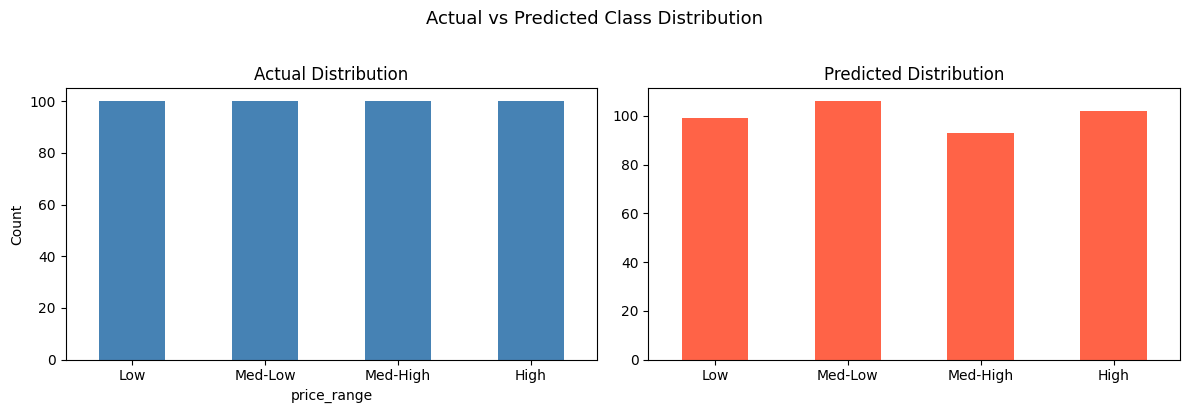

In [ ]:
# Actual vs Predicted class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["Low", "Med-Low", "Med-High", "High"]

pd.Series(y_test).value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Actual Distribution")
axes[0].set_xticklabels(labels, rotation=0)
axes[0].set_ylabel("Count")

pd.Series(y_pred_best).value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="tomato")
axes[1].set_title("Predicted Distribution")
axes[1].set_xticklabels(labels, rotation=0)

plt.suptitle("Actual vs Predicted Class Distribution", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## **Save Best Model**

In [ ]:
import pickle

with open("mobile_price_rf_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved as mobile_price_rf_model.pkl")

Model saved as mobile_price_rf_model.pkl


In [ ]:
# Load and verify
with open("mobile_price_rf_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

price_labels = {0: "Low", 1: "Medium-Low", 2: "Medium-High", 3: "High"}
sample       = X_test.iloc[:5]
preds        = loaded_model.predict(sample)
print("Sample Predictions:", [price_labels[p] for p in preds])

Sample Predictions: ['High', 'Medium-Low', 'Low', 'Medium-Low', 'High']
